In [2]:
import pandas as pd ## Basic libraries for data handling
import numpy as np

import matplotlib.pyplot as plt  # For plotting
import seaborn as sns

from sklearn.model_selection import train_test_split # For ML model, splitting data, and evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import os # For finding the dataset file automatically

ModuleNotFoundError: No module named 'seaborn'

In [20]:
# When you create a notebook from the dataset page, Kaggle puts files in /kaggle/input/
# This loop just prints every file so you can see the exact path/name
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/birdy654/deep-voice-deepfake-voice-recognition/KAGGLE/DATASET-balanced.csv
/kaggle/input/datasets/birdy654/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/FAKE/trump-to-Obama.wav
/kaggle/input/datasets/birdy654/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/FAKE/margot-to-musk.wav
/kaggle/input/datasets/birdy654/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/FAKE/linus-to-obama.wav
/kaggle/input/datasets/birdy654/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/FAKE/taylor-to-trump.wav
/kaggle/input/datasets/birdy654/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/FAKE/taylor-to-biden.wav
/kaggle/input/datasets/birdy654/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/FAKE/ryan-to-trump.wav
/kaggle/input/datasets/birdy654/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/FAKE/obama-to-musk.wav
/kaggle/input/datasets/birdy654/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO/FAKE/musk-to-trump.wav
/kaggle/input/datasets/birdy654/deep-voice-deep

In [21]:
df = pd.read_csv("/kaggle/input/datasets/birdy654/deep-voice-deepfake-voice-recognition/KAGGLE/DATASET-balanced.csv")

print(df.shape)     
df.head()             

(11778, 27)


,chroma_stft,rms,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,mfcc1,mfcc2,mfcc3,mfcc4,...,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,LABEL
0,0.338055,0.027948,2842.948867,4322.916759,6570.586186,0.041050,-462.169586,90.311272,19.073769,24.046888,...,-6.686564,0.902086,-7.251551,-1.198342,4.747403,-4.986279,0.953935,-5.013138,-6.779060,FAKE
1,0.443766,0.037838,2336.129597,3445.777044,3764.949874,0.047730,-409.413422,120.348808,-7.161531,5.114784,...,-2.131157,-6.876417,-1.359395,0.326401,-5.420016,-2.109968,-1.757634,-9.537907,-8.494421,FAKE
2,0.302528,0.056578,2692.988386,2861.133180,4716.610271,0.080342,-318.996033,120.490273,-24.625771,23.891073,...,-5.853725,-3.724773,-6.627182,-5.117002,-6.072106,-0.994653,-1.617120,-3.922354,-7.033001,FAKE
3,0.319933,0.031504,2241.665382,3503.766175,3798.641521,0.047180,-404.636749,136.320908,2.308172,-3.907071,...,-1.898315,-2.046493,-7.176277,-3.293508,4.209121,0.121835,-5.407063,-3.654926,-3.274857,FAKE
4,0.420055,0.016158,2526.069123,3102.659519,5025.077899,0.051905,-410.497925,152.731400,-18.266771,51.993462,...,-1.952340,0.810868,6.238493,6.555839,7.535542,2.849219,2.616843,-1.793357,-5.060998,FAKE


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11778 entries, 0 to 11777
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   chroma_stft         11778 non-null  float64
 1   rms                 11778 non-null  float64
 2   spectral_centroid   11778 non-null  float64
 3   spectral_bandwidth  11778 non-null  float64
 4   rolloff             11778 non-null  float64
 5   zero_crossing_rate  11778 non-null  float64
 6   mfcc1               11778 non-null  float64
 7   mfcc2               11778 non-null  float64
 8   mfcc3               11778 non-null  float64
 9   mfcc4               11778 non-null  float64
 10  mfcc5               11778 non-null  float64
 11  mfcc6               11778 non-null  float64
 12  mfcc7               11778 non-null  float64
 13  mfcc8               11778 non-null  float64
 14  mfcc9               11778 non-null  float64
 15  mfcc10              11778 non-null  float64
 16  mfcc

In [23]:
# Find the column that holds the label (real/fake).
# It's usually the last column or named something like 'LABEL' or 'class'.
# Run this to see all column names:
print(df.columns.tolist())

['chroma_stft', 'rms', 'spectral_centroid', 'spectral_bandwidth', 'rolloff', 'zero_crossing_rate', 'mfcc1', 'mfcc2', 'mfcc3', 'mfcc4', 'mfcc5', 'mfcc6', 'mfcc7', 'mfcc8', 'mfcc9', 'mfcc10', 'mfcc11', 'mfcc12', 'mfcc13', 'mfcc14', 'mfcc15', 'mfcc16', 'mfcc17', 'mfcc18', 'mfcc19', 'mfcc20', 'LABEL']


In [24]:
# Once you spot the label column name, check class balance
label_col = "LABEL"   # <-- change this to match your actual column name
df[label_col].value_counts()

LABEL
FAKE    5889
REAL    5889
Name: count, dtype: int64

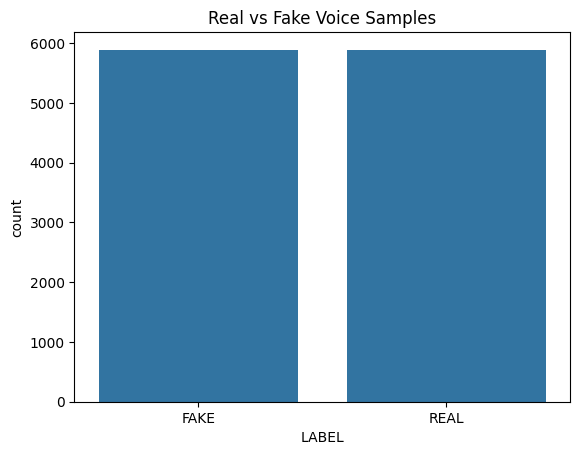

In [25]:
# Visualize the class balance
sns.countplot(x=label_col, data=df)
plt.title("Real vs Fake Voice Samples")
plt.show()

In [26]:
# Separate features (X) from the label (y)
X = df.drop(columns=[label_col])
y = df[label_col]

# If y is text (e.g. "REAL"/"FAKE"), convert to numbers
if y.dtype == object:
    y = y.map({y.unique()[0]: 0, y.unique()[1]: 1})
    print("Mapped:", {y.unique()[0]: 0, y.unique()[1]: 1})

# Drop any non-numeric columns from X (e.g. filenames) if present
X = X.select_dtypes(include=[np.number])

Mapped: {np.int64(0): 0, np.int64(1): 1}


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (9422, 26) Test size: (2356, 26)


In [28]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [29]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9923599320882852

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1178
           1       0.99      0.99      0.99      1178

    accuracy                           0.99      2356
   macro avg       0.99      0.99      0.99      2356
weighted avg       0.99      0.99      0.99      2356



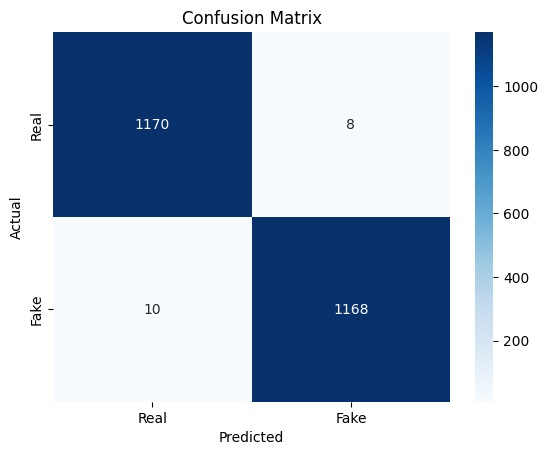

In [30]:
# Confusion matrix — visual view of correct/incorrect predictions
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

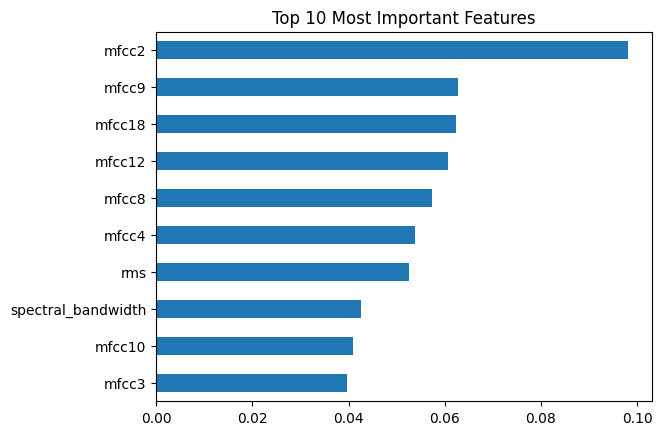

In [31]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

In [32]:
def get_impersonation_risk(sample_features):
    """
    Takes one row of audio features and returns a risk score + recommendation.
    sample_features: a pandas Series or 1-row DataFrame with the same columns as X
    """
    prob_fake = model.predict_proba([sample_features])[0][1]  # probability of being "fake"
    risk_score = round(prob_fake * 100, 2)

    if risk_score >= 70:
        recommendation = "HIGH RISK — Trigger call-back verification before proceeding."
    elif risk_score >= 40:
        recommendation = "MEDIUM RISK — Recommend secondary authentication."
    else:
        recommendation = "LOW RISK — Safe to proceed."

    return risk_score, recommendation

# Test it on one sample from the test set
sample = X_test.iloc[0]
score, rec = get_impersonation_risk(sample)
print(f"Impersonation Risk Score: {score}%")
print(f"Recommendation: {rec}")

Impersonation Risk Score: 96.5%
Recommendation: HIGH RISK — Trigger call-back verification before proceeding.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [33]:
import joblib

# Save the trained model to a file
joblib.dump(model, "voice_fraud_detector.pkl")

# Also save the exact column order the model expects — critical for matching later
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Saved! Go to the Output tab on the right sidebar and download both files.")

Saved! Go to the Output tab on the right sidebar and download both files.


In [34]:
print(df.columns.tolist())


['chroma_stft', 'rms', 'spectral_centroid', 'spectral_bandwidth', 'rolloff', 'zero_crossing_rate', 'mfcc1', 'mfcc2', 'mfcc3', 'mfcc4', 'mfcc5', 'mfcc6', 'mfcc7', 'mfcc8', 'mfcc9', 'mfcc10', 'mfcc11', 'mfcc12', 'mfcc13', 'mfcc14', 'mfcc15', 'mfcc16', 'mfcc17', 'mfcc18', 'mfcc19', 'mfcc20', 'LABEL']
